In [22]:
from Bio import SeqIO
import numpy as np
import matplotlib.pyplot as plt

neanderthal = str(SeqIO.read('neanderthal.fasta', 'fasta').seq).upper()
human       = str(SeqIO.read('human.fasta',       'fasta').seq).upper()

print(f'Неандерталец: {len(neanderthal)} bp')
print(f'Человек:      {len(human)} bp')

Неандерталец: 16565 bp
Человек:      16569 bp


In [23]:
def dotplot_kmer(seq1, seq2, k=10):

    index = {}
    for i in range(len(seq1) - k + 1):
        kmer = seq1[i:i+k]
        if kmer not in index:
            index[kmer] = []
        index[kmer].append(i)

    xs, ys = [], []
    for j in range(len(seq2) - k + 1):
        kmer = seq2[j:j+k]
        if kmer in index:
            for i in index[kmer]:
                xs.append(j) 
                ys.append(i)  

    print(f'Найдено точек совпадений: {len(xs)}')
    return xs, ys


xs, ys = dotplot_kmer(neanderthal, human, k=10)

Найдено точек совпадений: 15514


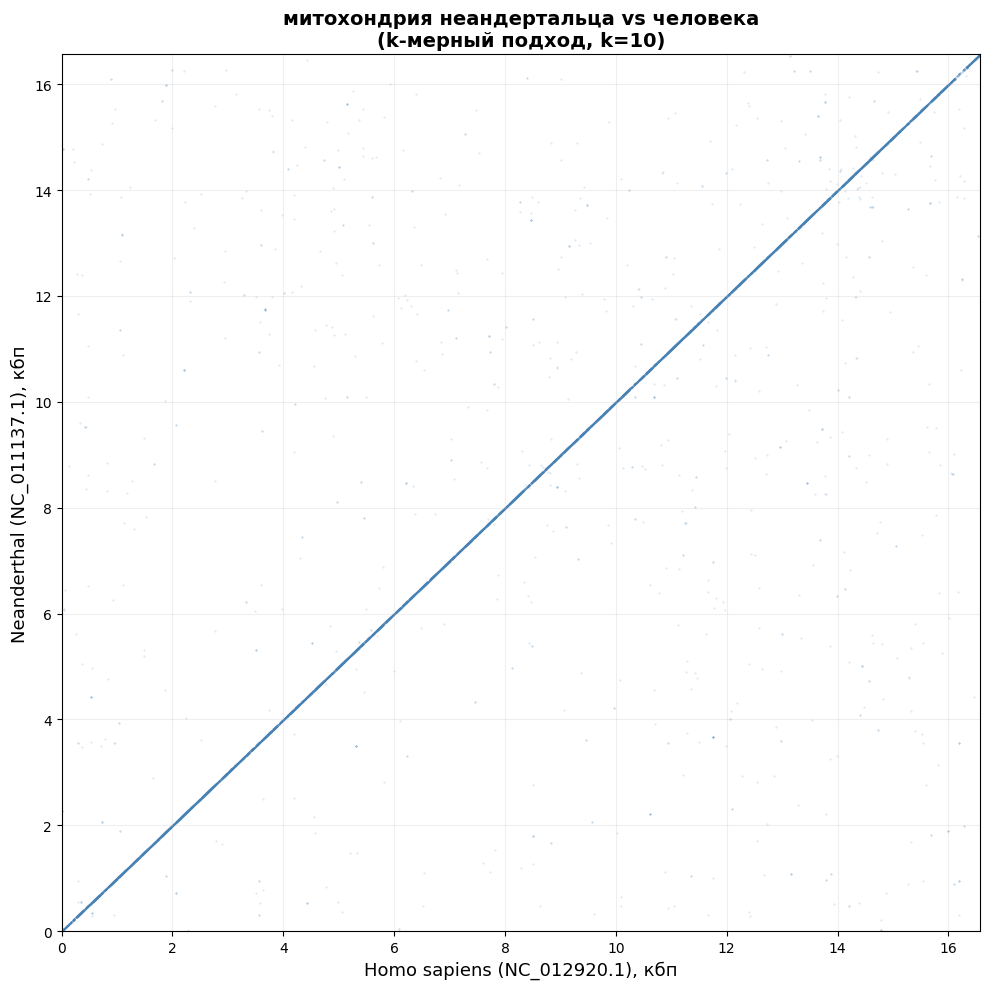

In [24]:
fig, ax = plt.subplots(figsize=(10, 10))

ax.scatter(
    np.array(xs) / 1000,
    np.array(ys) / 1000,
    s=0.1, color='steelblue', alpha=0.3, rasterized=True
)

ax.set_xlabel('Homo sapiens (NC_012920.1), кбп', fontsize=13)
ax.set_ylabel('Neanderthal (NC_011137.1), кбп', fontsize=13)
ax.set_title('митохондрия неандертальца vs человека\n(k-мерный подход, k=10)',
             fontsize=14, fontweight='bold')
ax.set_xlim(0, len(human) / 1000)
ax.set_ylim(0, len(neanderthal) / 1000)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('dotplot_mito.png', dpi=200, bbox_inches='tight')
plt.show()